# Titanic Data Dictionary

| Column Name | Description | Values / Notes |
| :--- | :--- | :--- |
| **PassengerId** | Passenger Identity Number | Unique for each passenger |
| **Survived** | Survival Status | 0 = No, 1 = Yes |
| **Pclass** | Ticket Class | 1 = Upper, 2 = Middle, 3 = Lower |
| **Name** | Passenger Name | Name and Title (Mr, Mrs, etc.) |
| **Sex** | Sex | male, female |
| **Age** | Age | Age in years |
| **SibSp** | Number of Siblings/Spouses Aboard | Sibling / Spouse |
| **Parch** | Number of Parents/Children Aboard | Parent / Children |
| **Ticket** | Ticket Number | - |
| **Fare** | Fare | Fare paid per passenger |
| **Cabin** | Cabin Number | - |
| **Embarked** | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |


In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
    

In [3]:
# Loading training and test datasets
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

Standard Data Preprocessing and Analysis Steps:
1. Descriptive Analysis (Data Understanding): First look at the data (head, info, describe). Understanding data types and general structure.
2. Missing Value Analysis and Treatment: Detection, deletion, or imputation (with mean/mode/median) of missing data.
3. Duplicate Record Analysis: Checking and cleaning duplicate rows.
4. Outlier Analysis: Detecting and removing or suppressing extreme values that distort the overall distribution of data.
5. Univariate Analysis: Examining the distribution of each column individually (with charts).
6. Feature Engineering: Generating new columns from existing data.
7. Bivariate/Multivariate Analysis: Relationships between variables and with the target (Correlation, Heatmap).
8. Data Preparation: Converting text to numbers for machine learning (Label/One-Hot Encoding) and scaling numerical values (Scaling).


#### 1. Descriptive Analysis - Data Understanding


In this first part, 3 basic Python functions are used to understand the structure, size, and general characteristics of the data:
    
* **A. df.head() - Quick Look at Data**
    
    - Getting an idea about the content of columns by viewing the first few rows of the dataset.
    - Is the data string, numeric, or date? Are column names descriptive?
    
* **B. df.info() - Technical Structure of Data**
    - Seeing how many rows/columns there are in total and how many **missing (null)** data points in each column.
    - Are the data types (int, float, object) correct? What is memory usage?
    - **Numerical Data:** Data on which mathematical operations can be performed.
        - **Discrete:** Takes only integer values.
        - **Continuous:** Can take decimal values in any range.
    - **Categorical Data:** Used to divide data into groups.
        - **Nominal:** There is no size/rank relationship between groups.
        - **Ordinal:** There is a hierarchical order between groups.
    - **Text Data (Text/Object):** Unstructured information that usually varies for each row.


* **C. df.describe() - Statistical Summary**
    - Seeing the mathematical summary (mean, min, max, quartiles) of numeric columns.
    - **Mean vs Median (50%):** If there is a large gap between them, there is a high probability of **outliers** in the data.
    - **Min/Max:** Are the data limits reasonable? (e.g., Age being -5 is an error.)

| Statistic | Technical Description | Use in Analysis / Real Life Equivalent |
| :--- | :--- | :--- |
| **Count** | Number of non-empty data points | **Missing Data Strategy:** If count is less than the total, cleaning/imputation is required in that column. |
| **Mean** | Arithmetic Mean | **General Profile:** Answers the question "What did an average passenger spend?" |
| **std (Deviation)** | Distance from mean | **Risk and Diversity:** If the number is small, the data points are similar; if it is large, it means there are very different ages/prices. |
| **Min / Max** | Smallest and largest values | **Error and Clue:** Catches data entry errors (Age cannot be -5) or extreme cases ($512 ticket). |
| **50% (Median)** | Middle value | **Realistic Center:** Provides a more reliable center point than the mean if there are outliers in the data. |
| **25% / %75** | Quartiles | **Segmentation:** Dividing the data into 4 parts allows separating the lowest and highest segments. |


In [4]:

# look at the first 5 rows
print("--- first 5 rows ---")
display(train_df.head())

print("--- data summary ---")
display(train_df.describe())

print("--- dataset information ---")
display(train_df.info())

--- first 5 rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


--- data summary ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


--- dataset information ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

- The survival rate is approximately 38% on average. This shows that only about 38% of the people on the ship survived; the majority perished.

- While the number of data points in columns is 891, the age column has 714 data points. The ages of 177 people are unknown.
- In ticket prices, the maximum is 512.3 - average price 32.2 - minimum price 0. There is an unbalanced price difference here; some tickets were bought at very high prices while others were bought at very low prices.
- It can be seen that there are passengers with no siblings/spouses (SibSp=0, Min=0) and at least one passenger who brought 8 people (siblings/spouses) with them.
- When looking at the ticket class, the average corresponds to 2.3. This shows that the majority of ticket buyers were from the lower and middle classes.
- Regarding missing values, data for 177 people is missing in the 'Age' column, which may affect the accuracy of the predictions. However, I think that if I can fill the missing parts of this column randomly with its mean and standard range, I can increase the accuracy slightly. But in the 'Cabin' column, there is more loss than raw information, which minimizes consistent filling for this column. I cannot use this column for predictions and analysis, so I will delete it.
- At the port of embarkation, data for two people is missing; I will fill this part according to the mode.
- When checking data types:

    - `Sex` and `Embarked` columns currently appear as objects (plain text). Since these actually consist of certain classes (such as male/female), converting them to **category** type provides both memory savings and faster analysis.
    
    - `Survived` and `Pclass` columns appear as (int64), but they are actually categorical data. There can be no class 1.5 or 0.7 survival status. It may be logical to convert these to `category` or a smaller integer type.
    - It is correct that the `Age` column is `float64` (decimal) because the ages of babies can come in as 0.42. 


### 2. Missing Value Treatment and Data Cleaning
    
    
Data cleaning is the most critical step of the analysis phase. Missing data (Null/NaN) should be managed in a dataset in the following ways:


#### A. Understanding Missing Data
First, why the missing data occurred should be questioned. Was it a data entry error or does the absence of that data carry a meaning? (e.g., the absence of `Cabin` information might indicate that person did not have a cabin).

#### B. Common Strategies
1. **Dropping Column / Row (Drop):** 
    - Used if more than 60-70% of a column is missing and filling it would distort the data too much.
    - Can lead to significant information loss.

2. **Constant Imputation:**
    - Used when we want to assign a special meaning to missing data (e.g., writing "Unknown" or "0" in empty places).

3. **Numerical Imputation:**
    - **Mean:** Preferred for normally distributed data.
    - **Median:** More reliable if there are outliers and the data is skewed.
    - **Mode:** Generally used in **categorical** data to assign the most frequently repeating group.

4. **Advanced Imputation:**
    - Gaps can be filled with algorithms that predict based on other columns (KNN, Regression, etc.).
> **Important Rule:** After cleaning, make sure everything is 0 with the `isnull().sum()` command. The next step (Outlier or Visualization) should not be started until the dataset is clean.




In [5]:
# dropping unnecessary column
if 'Cabin' in train_df.columns:
    train_df.drop('Cabin', axis=1, inplace=True)

# filling the Age column with reasonable random numbers
mean_age=train_df['Age'].mean()
std_age=train_df['Age'].std()
null_count=train_df['Age'].isnull().sum()

if null_count > 0:
    # generating random ages in the range of mean +- 1 standard deviation
    random_ages=np.random.randint(mean_age-std_age, mean_age+std_age, size=null_count)
    train_df.loc[train_df['Age'].isnull(), 'Age']=random_ages

# converting ages to integers
train_df['Age']=train_df['Age'].astype(int)

# filling the Embarked column with the most common value (Mode)
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# optimizing data types - making categorical
categorical_cols=['Survived', 'Pclass', 'Sex', 'Embarked']

for col in categorical_cols:
    train_df[col]=train_df[col].astype('category')

In [6]:
print("Missing Value Count:\n", train_df.isnull().sum())
print("\nNew Data Types:\n", train_df.dtypes)

Missing Value Count:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

New Data Types:
 PassengerId       int64
Survived       category
Pclass         category
Name                str
Sex            category
Age               int64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Embarked       category
dtype: object


### 3. Duplicate Analysis
In the data collection or merging phases, identical rows (same information) can sometimes be entered into the system two or more times. This situation can lead to the model learning the same data repeatedly and "memorizing" it (Overfitting), thus distorting the results.

- **duplicate():** Used to check whether rows are copies of each other.
- **drop_duplicates():** If duplicate rows are found, it deletes them so that only one remains.

In [7]:
# finding completely identical rows in the dataset
duplicate_count=train_df.duplicated().sum()

print(f"Number of duplicate rows in the dataset: {duplicate_count}")

if duplicate_count > 0:
    train_df.drop_duplicates(inplace=True)
    print("Duplicate records cleared.")
else:
    print("No duplicate rows in the dataset")

Number of duplicate rows in the dataset: 0
No duplicate rows in the dataset


### 4. Outlier Detection
    
Outliers are observations that are significantly distant from other observations in the dataset, meaning they do not fit the overall distribution of the data (e.g., a passenger paying $500 where most people pay $20-30).

Outlier analysis is usually meaningful for continuous numerical data. That is, in data that can take infinite values and can go "very far" on a number line.

Fare: Can take any number between 0 and 512. Going to 500 is an "outlier".
Age: Can take any number between 0 and 80. 80 is an extreme case.

Survived: Can only be 0 and 1. There cannot be a value like 10 (if there were, it would be an error, not an outlier).

Pclass (Ticket Class): Can only be 1, 2, and 3. It cannot exceed 3.

SibSp and Parch: Although these appear to be "numbers" (0, 1, 2... 8), they are like categories. Yes, a person with 8 siblings (max value) is an "extreme" case, but they do not create a massive mathematical deviation like $512 in the ticket price.

- Outliers can confuse unrealistic models (especially regression-based ones) and cause the mean to be incorrect.
- Generally, **Boxplot** is used. In this plot, "points that fall outside the box" are outliers.

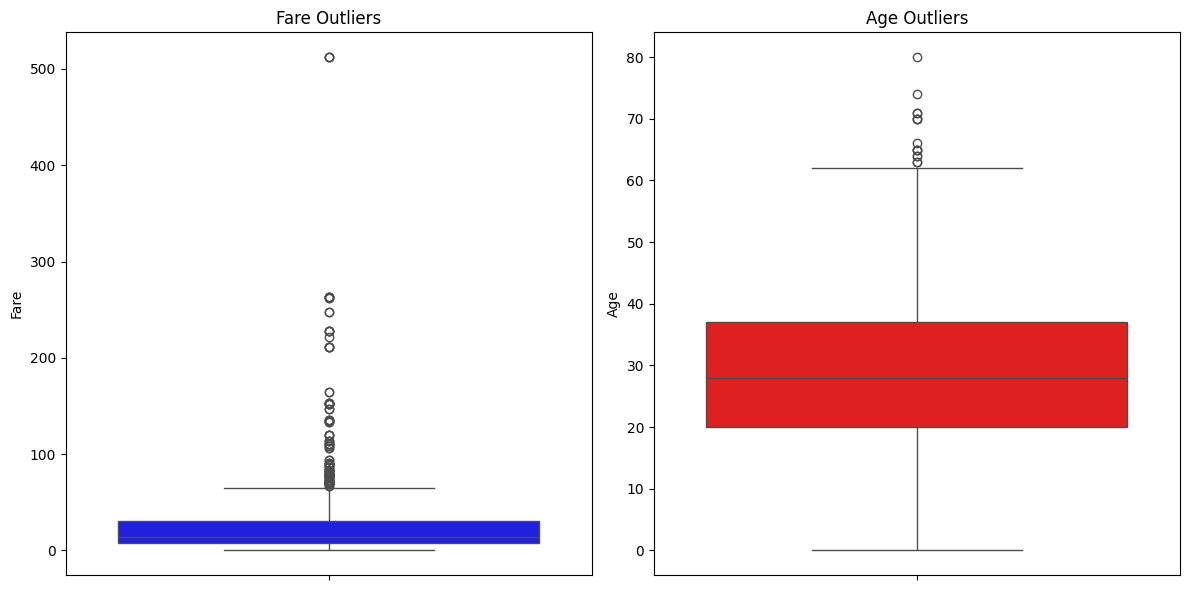

In [8]:
# Drawing Boxplots for numerical data
plt.figure(figsize=(12,6))

# Looking at outliers for Fare and Age
plt.subplot(1,2,1)
sns.boxplot(y=train_df['Fare'], color='blue')
plt.title('Fare Outliers')

plt.subplot(1,2,2)
sns.boxplot(y=train_df['Age'], color='red')
plt.title('Age Outliers')

plt.tight_layout()
plt.show()

### How to Read a Boxplot?

Each part in the chart has a meaning:

1. **Middle Line (Median):** The line in the middle of the box. Divides the data exactly in two.
2. **Box (Quartiles):** Represents the 50% segment right in the center of the data. 
    - Bottom edge: 25% (Q1)
    - Upper edge: 75% (Q3)
3. **Whiskers:** Vertical lines extending down and up. They draw the boundary of the smallest and largest values considered normal.
4. **Isolated Dots (Outliers):** Values that extend beyond even the whiskers. These are **outliers.**


<p align="center">
  <img src="box-distribution-graph.png" width="850">
</p>


#### Interpretation of Charts:

*   **Fare:** It is observed that the blue box is very compressed and has too many dots on it. This proves that the overwhelming majority of passengers paid very low fares, but a small group (dots) paid "extravagant" prices. This data has a **"right-skewed"** distribution.
*   **Age:** The red box stands wider and more centered. This indicates that age is distributed more balanced compared to ticket price. We only have a few outlier (very old) passengers over the age of 65.


##### Fare Analysis:

- There are too many dots on the box -blue area-. In particular, the top dot of $512 is a huge outlier. While most passengers pay between $0-50, those who pay over $100 look completely outlier.
Usually these values are not deleted because these people represent the "Rich" class and their chance of survival may be higher. However, these extreme values can cause trouble when training the model.


##### Age Analysis:

- People between 65-80 are seen as outliers. These people are "very old" passengers. Since their numbers are low, they stayed outside the statistical distribution. 80 years is not an impossible value for a human, it is real information, so these values are left as they are.

* 3 Ways to Deal with Outliers:
- Leave as It Is: If extreme values represent a real situation (like wealth).
- Capping: For example, fixing everything over $100 to $100.
- Deletion: If it is believed that data is an error.



**If outliers in the Titanic data go to very extreme points, these values can be suppressed.**

**If the outlier is not from an error (e.g., age entered as 500) but from a real situation (e.g., a very wealthy passenger), that data is actually important.**

### 5. Univariate Analysis

In this step, variables are taken one by one and the distribution of each within the dataset is examined. Answers to questions such as "How many people survived?", "How was the gender distribution?", "In which class were the passengers most common?" are obtained by visualizing in this section.

- **For Categorical Data:** Pie Chart or Bar Chart (Countplot) is used.
- **For Numerical Data:** Histogram or Density plot (KDE) is used.


/tmp/ipykernel_14107/2398419170.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=train_df, palette='pastel')
/tmp/ipykernel_14107/2398419170.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=train_df, palette='Set2')
/tmp/ipykernel_14107/2398419170.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Embarked', data=train_df, palette='muted')


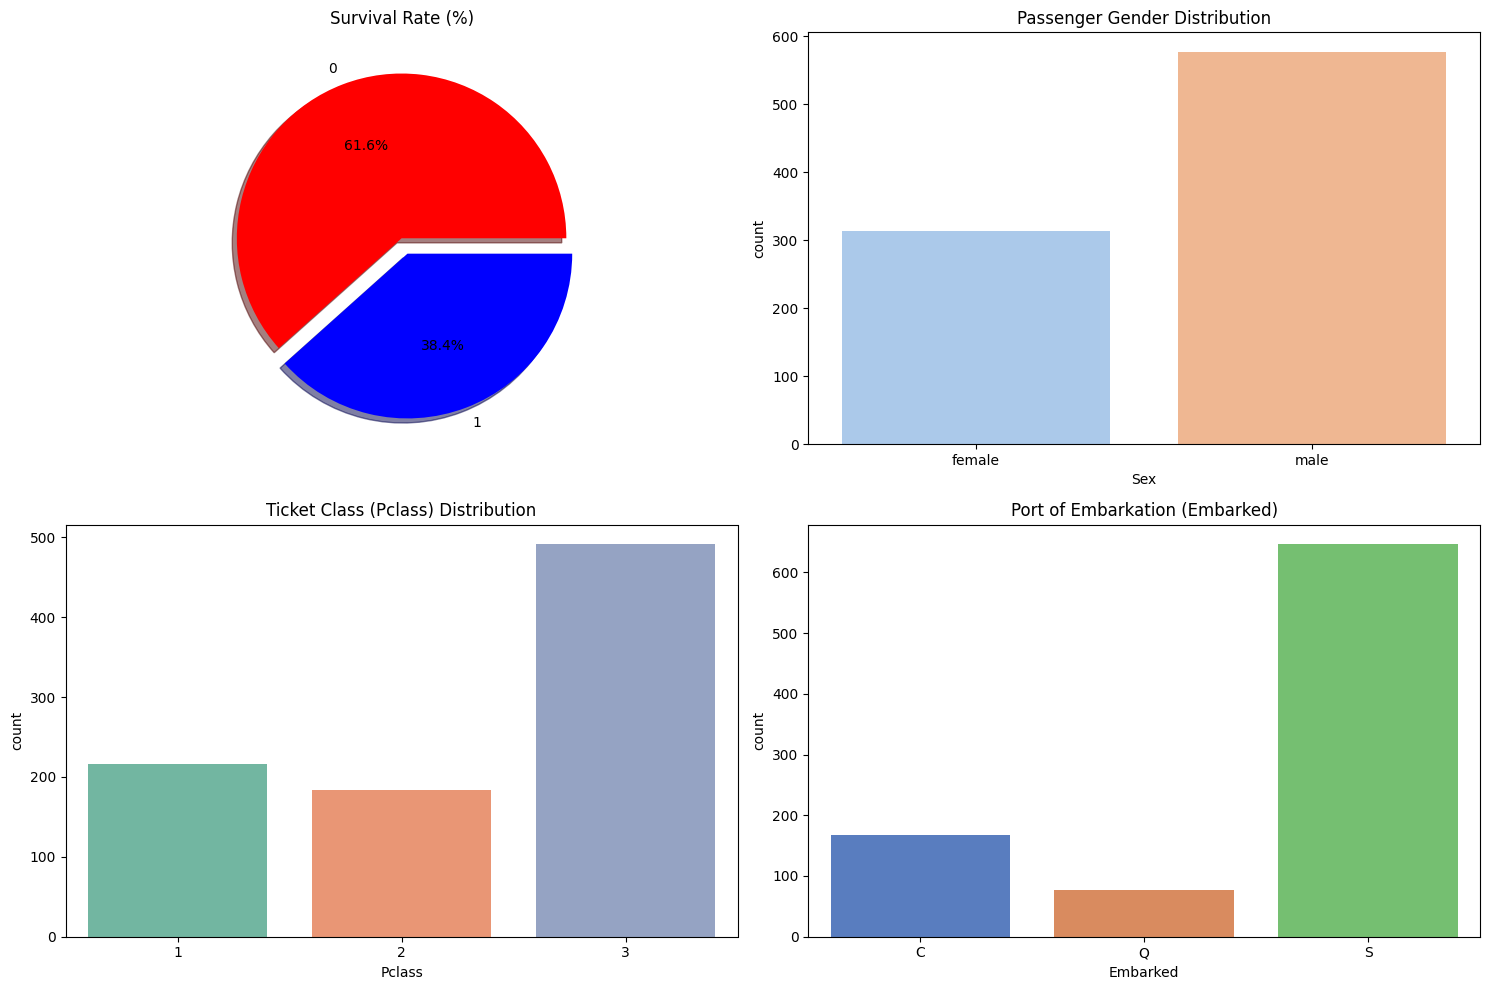

In [9]:
plt.figure(figsize=(15,10))

# hayatta kalma orani - target variable
plt.subplot(2,2,1)
train_df['Survived'].value_counts().plot.pie(explode=[0,0.1], autopct='%1.1f%%', shadow=True, colors=['red', 'blue'])
plt.title('Survival Rate (%)')

# Sex Dagilimi
plt.subplot(2,2,2)
sns.countplot(x='Sex', data=train_df, palette='pastel')
plt.title('Passenger Gender Distribution')


# Bilet Sinifi Dagilimi
plt.subplot(2,2,3)
sns.countplot(x='Pclass', data=train_df, palette='Set2')
plt.title('Ticket Class (Pclass) Distribution')

# Gemiye Binis Limani Dagilimi
plt.subplot(2,2,4)
sns.countplot(x='Embarked', data=train_df, palette='muted')
plt.title('Port of Embarkation (Embarked)')

plt.tight_layout()
plt.show()

##### Categorical data
- More than half of the passengers could not be saved. This can be considered an unbalanced dataset, meaning the "death data" is more dominant.

- The number of males on the ship is almost twice the number of females. There is a large male density on the ship.
- The number of 3rd class passengers is more than the sum of all other classes. This may suggest that "economic status" played a major role in survival on the ship.
- The vast majority of passengers boarded from the *Southampton (S)* port. *Queenstown (Q)* is the port with the fewest passengers.

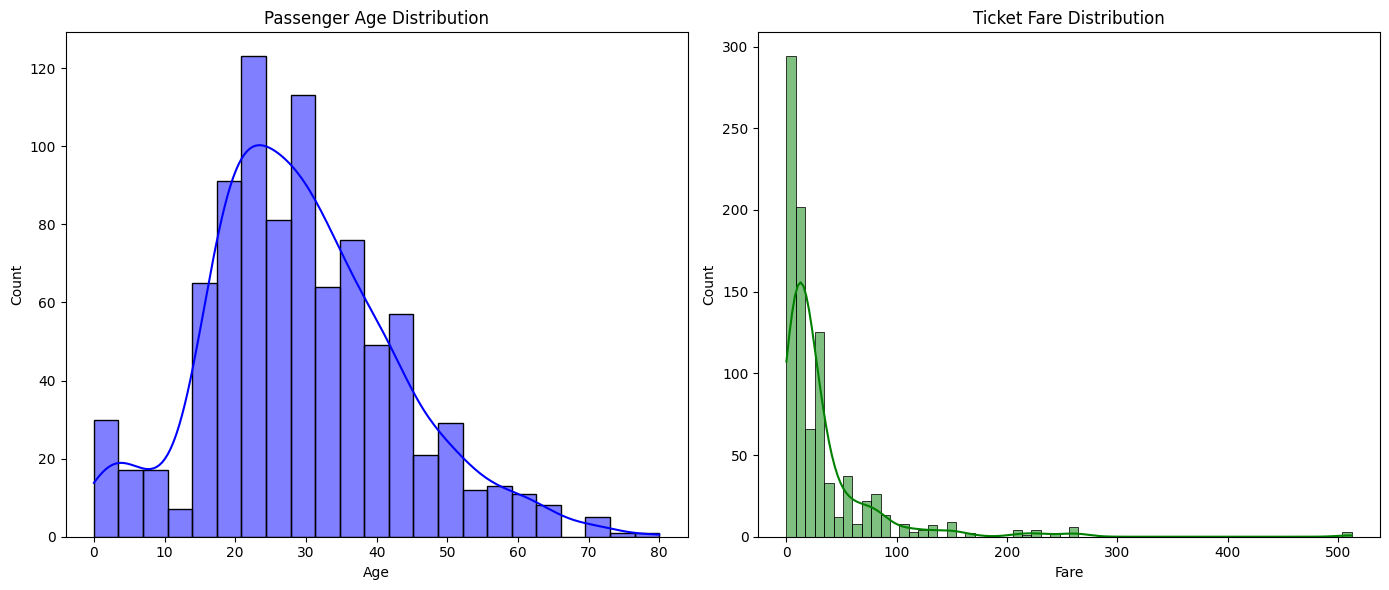

In [11]:
##### Numerical Data Analysis

plt.figure(figsize=(14,6))

# Age Distribution (Histogram)
plt.subplot(1,2,1)
sns.histplot(train_df['Age'], kde=True, color='blue')
plt.title('Passenger Age Distribution')

# Fare Distribution (Histogram)
plt.subplot(1,2,2)
sns.histplot(train_df['Fare'], kde=True, color='green')
plt.title('Ticket Fare Distribution')

plt.tight_layout()
plt.show()

##### Numerical Data Analysis
- The largest group on the ship is young adults between 18-35 years old.
- There is a peak in the infant group between 0-5 years old. This shows that there are a number of babies/small children on the ship.
- According to the data, the size of the group after age 60 drops rapidly. The distribution is relatively close to a normal distribution, but right-skewness is somewhat dominant and the tail is slightly to the right.
- The ticket fare distribution chart is extremely right-skewed; it's evident that ticket prices are generally well below average, with a tail to the right indicating that there are some people who bought very high-priced tickets.

### 6. What is Feature Engineering?
Feature Engineering is the process of generating new features (columns) using information in the existing dataset to **improve the learning of the machine learning model**. Raw data is not always presented in its most meaningful form for the model.
#### Why is it Necessary?
1. **Simplifying Complexity:** For example, how many siblings and how many children a person has are separate pieces of information. But the question "Did they come with family or alone?" is more relevant to the survival model.
2. **Revealing Hidden Relationships:** Titles like "Dr." or "Master" extracted from names add **social status** information that age or sex data alone cannot provide.
3. **Improving Model Performance:** A well-chosen feature presents patterns to the model "on a silver platter," which even a complex artificial intelligence model might not otherwise see.
#### Frequently Used Techniques:
- **Aggregation:** Adding or multiplying two or more columns (e.g., `FamilySize`).
- **Extraction:** Extracting a meaningful part from a text (e.g., extracting title from name).
- **Grouping / Binning:** Dividing ages into ranges like 0-10, 10-20.
- **Transformation:** Normalizing widely distributed numbers (like Fare) by taking their logarithm.


<>:11: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:11: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/tmp/ipykernel_14107/4031773870.py:11: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
/tmp/ipykernel_14107/4031773870.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y=train_df['Survived'].astype(int), data=train_df, palette='magma')
/tmp/ipykernel_14107/4031773870.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is de

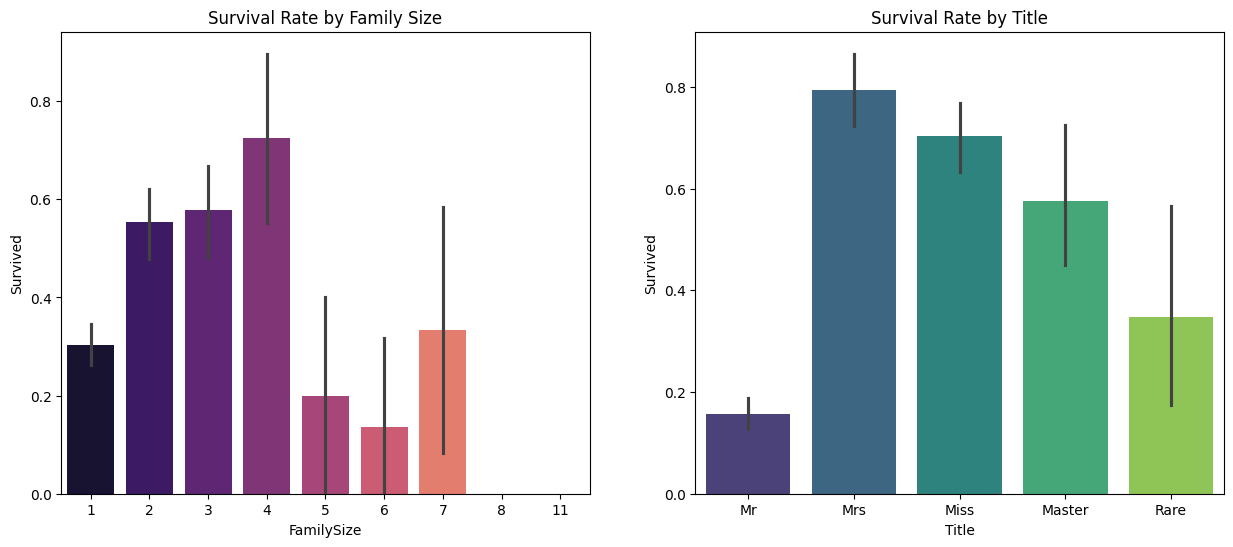

In [12]:
# Family Size and Solitary Status
# Calculation: Self (1) + Siblings/Spouse (SibSp) + Parents/Children (Parch)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

# Mark those who are alone (1: Alone, 0: Not Alone)
train_df['IsAlone'] = 0
train_df.loc[train_df['FamilySize'] == 1, 'IsAlone'] = 1

# Extracting Titles from names
# Extracts the word starting after a space and ending before a period
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Grouping Titles (Categorize rare ones as 'Rare')
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace('Mlle', 'Miss') # Mademoiselle -> Miss
train_df['Title'] = train_df['Title'].replace('Ms', 'Miss')   # Ms -> Miss
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')    # Madame -> Mrs

plt.figure(figsize=(15,6))

# Survival Rate by Family Size
plt.subplot(1,2,1)
sns.barplot(x='FamilySize', y=train_df['Survived'].astype(int), data=train_df, palette='magma')
plt.title('Survival Rate by Family Size')

# Survival Rate by Title
plt.subplot(1,2,2)
sns.barplot(x='Title', y=train_df['Survived'].astype(int), data=train_df, palette='viridis')
plt.title('Survival Rate by Title')

plt.show()

- As seen in the chart, the survival chance of those traveling alone is around 30%.
- However, the chance for small families of 2, 3, or 4 people varies between 50%-75%.
- Small families might have supported each other. However, when family size increases to 5 and above, the chance of survival drops significantly.

- The survival rate for ordinary men with the title "Mr" is very low, about 15%-20%.
- Women with titles "Mrs" and "Miss" survived at a high rate of 70%-80%. For small boys titled "Master", if only the male gender was considered, the survival rate would be low, but thanks to their titles, it can be said they had about a 60% chance of survival.
- Countess - A female title of nobility in the European hierarchy (the wife of an Earl/Count or the person herself). On the far right of the chart, she appears to have a 100% survival rate. It seems that nobility indeed affects the survival rate.

*****Feature Engineering is very important. As seen from the charts, if only sex was considered, the nobility category would be ignored, which could lower the model's success.*****

### 7. Bivariate/Multivariate Analysis (Correlation Heatmap)

In this final analysis phase, we will examine the relationship of all numerical variables, including newly generated features like `FamilySize` and `IsAlone`, with each other and the survival status.


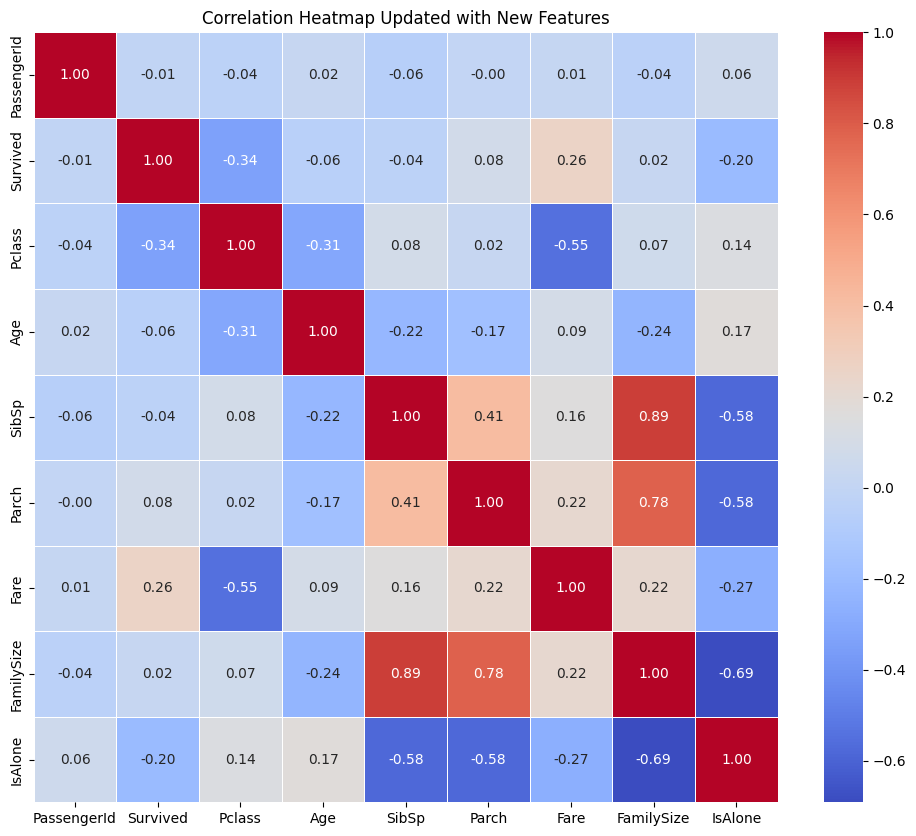

In [13]:
# Select numerical data along with new columns for correlation
# Note: Since 'Survived' is categorical, include it by converting it back to integer
corr_data = train_df.copy()
corr_data['Survived'] = corr_data['Survived'].astype(int)
corr_data['Pclass'] = corr_data['Pclass'].astype(int)

# Select numerical columns
numeric_corr = corr_data.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap Updated with New Features')
plt.show()


Heatmap Evaluation:

Survived & Pclass (Approx. -0.34): The negative relationship here is very important. As the ticket class number increases (from 1 to 3), the chance of survival decreases. In other words, the social stratum on the ship is one of the strongest factors determining survival.

Survived & Fare (Approx. +0.26): The positive relationship here statistically proves that as the amount paid increases, the chance of survival also increases.

Survived & FamilySize (Approx. +0.02): It was seen in the bar chart that small families (2-4 people) had high chances. Since correlation looks for a straight line relationship, it shows this complex (first rising, then falling) relationship as low here.

FamilySize & SibSp/Parch (Approx. +0.80 - +0.90): `FamilySize` was created by adding these two. The "perfect" bond between them shows the correctness of the process.







### 8. Data Preparation
Machine learning models cannot put texts like "male/female" into mathematical processes. Therefore, all data should be brought into numerical form:
1. **Label Encoding:** For data with two options (e.g., `Sex`: Male=0, Female=1).
2. **One-Hot Encoding:** Creating new columns for data with three or more options (e.g., `Title_Mr`, `Title_Mrs`).
3. **Scaling:** To prevent large numbers like `Fare` (500) from overpowering small numbers like `Age` (20), bringing all numerical values to a similar range (e.g., between 0 and 1).


In [14]:
# Required library
from sklearn.preprocessing import LabelEncoder

# Convert Sex to number (male: 0, female: 1)
le = LabelEncoder()

train_df['Sex'] = le.fit_transform(train_df['Sex'])

# Perform One-Hot Encoding on multi-option data like Embarked and Title
train_df = pd.get_dummies(train_df, columns=['Embarked', 'Title'], drop_first=True)

# Drop columns like Name and Ticket that won't be used in the model
train_df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

# Check
print("Dataset After Preparation:")
display(train_df.head())


Dataset After Preparation:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,1,22,1,0,7.2500,2,0,False,True,False,True,False,False
1,1,1,0,38,1,0,71.2833,2,0,False,False,False,False,True,False
2,1,3,0,26,0,0,7.9250,1,1,False,True,True,False,False,False
3,1,1,0,35,1,0,53.1000,2,0,False,True,False,False,True,False
4,0,3,1,35,0,0,8.0500,1,1,False,True,False,True,False,False
